# Day 1-03｜課後銜接任務：建立球員偵測的 Bounding Box 資料

> 這份 notebook 的重點是**準備 Day 2 會用到的資料**，不是提前重講完整 YOLO 推論。  
> 我們會完成少量圖片的框選、資料版本發布與格式檢查；Day 2 再專注觀察模型如何輸出偵測框。

## 我們會完成什麼

- 為球員、球、籃框等物件定義一致的類別名稱。
- 在 Roboflow 上傳並標註課程提供的少量圖片。
- 發布 dataset version，下載成 YOLO detection 格式並檢查資料夾。
- 選做：使用老師提供的模型跑一張驗證圖，確認資料流程已接通。

## 先認識本單元名詞

- **Bounding box / BBOX（邊界框）**：用左上角與右下角包住物件的矩形。
- **Class（類別）**：框內物件的名稱，例如 `player` 或 `ball`。
- **Dataset version（資料集版本）**：固定當下標註與切分的可重現快照；只有發布後才能由 API 下載。
- **Homework 與 Day 2 的分工**：今天產生資料，明天解讀模型輸出，兩者不重複。


## 執行環境提醒

- 建議在 Colab 選擇 **GPU** 執行階段；Ultralytics / PyTorch 不會在本課程設定下直接使用 TPU。
- 沒有 GPU 仍可用 CPU 執行，但模型推論與影片輸出會比較久。先把 `MAX_FRAMES` 調小，就能快速確認流程。
- 每格執行前先讀「這一格要做什麼」，再看輸出是否符合預期；不要只以「沒有紅字」判斷成功。


## 工作坊流程（資料準備，不重講推論）

1. 解壓課程提供的 5 張圖片並上傳 Roboflow。
2. 依統一類別規格畫 BBOX；每個框要貼近物件，但不要切掉身體主要部分。
3. 在 `Versions` 建立並發布 dataset version。
4. 回到 notebook 下載並檢查 `data.yaml`、images、labels 是否成對。
5. 選做快速預覽：只確認模型與資料能連通；confidence 與錯誤案例留到 Day 2 詳談。

### 交付檢查

- 至少 5 張圖片完成標註。
- 類別名稱與課程規格一致。
- 能說明一個「框太鬆、框太緊或類別錯誤」會造成的問題。


In [1]:
# 這一格要做什麼：定位課程資料夾、必要時取得 repo，並載入共用的課程環境。
# 建議先執行原始設定；確認輸出後，再一次只改一個參數觀察差異。
from pathlib import Path
import subprocess
import sys

COURSE_ROOT_HINT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "course_setup.py").exists()),
    Path("/content/basketball_hackathon/course"),
)
if not (COURSE_ROOT_HINT / "src" / "course_setup.py").exists() and "google.colab" in sys.modules:
    COURSE_ROOT_HINT.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "git", "clone", "--depth", "1", "https://github.com/henry753951/basketball-hackathon-course.git", str(COURSE_ROOT_HINT)
    ], check=True)
if str(COURSE_ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT_HINT))

from src.course_setup import bootstrap_course_repo  # noqa: E402

COURSE_ROOT = bootstrap_course_repo(COURSE_ROOT_HINT)


課程根目錄: H:\Repos\basketball-hackathon-course
素材資料夾: H:\Repos\basketball-hackathon-course\assets
工具模組: H:\Repos\basketball-hackathon-course\src


## Roboflow YOLO Detection Export 格式
Roboflow 匯出 YOLO 格式後，請將整個 dataset 放在：

```text
assets/datasets/roboflow_bbox_yolo/
├── data.yaml
├── train/ 或 images/train + labels/train
├── valid/ 或 images/valid + labels/valid
└── test/  或 images/test  + labels/test
```

本課程使用的 detector 類別與參考專案一致：`ball`、`ball-in-basket`、`number`、`player`、`player-in-possession`、`player-jump-shot`、`player-layup-dunk`、`player-shot-block`、`referee`、`rim`。

若學生是在 Roboflow 網頁上補標註，請先手動發布新的 dataset version；只有新 version 才能被下面的 API 下載流程抓到。


In [2]:
# 這一格要做什麼：Roboflow YOLO Detection Export 格式
# 建議先執行原始設定；確認輸出後，再一次只改一個參數觀察差異。
from getpass import getpass
from src.roboflow_utils import DETECTION_CLASSES, dataset_status, ensure_roboflow_detection_dataset

BBOX_DATASET_DIR = COURSE_ROOT / "assets" / "datasets" / "roboflow_bbox_yolo"
DETECTOR_MODEL_PATH = (
    COURSE_ROOT / "assets" / "models" / "detectors" / "yolo26n_basketball_player_best.pt"
)

# 學生作業建議流程：
# 1. 解壓 assets/student_uploads/roboflow_bbox_student_upload_images.zip。
# 2. 到 Roboflow 的 DATA > Upload Data 上傳 5 張圖片。
# 3. 到 DATA > Annotate，在 Unassigned 點 Annotate Images，完成 bbox 標註。
# 4. 到 Versions 頁面按 Generate New Version / Publish。
# 5. 把新的 workspace / project / version 填在下面。
# 6. 將 USE_ROBOFLOW_DOWNLOAD 改成 True。
USE_ROBOFLOW_DOWNLOAD = False
ROBOFLOW_WORKSPACE = "YOUR_WORKSPACE"
ROBOFLOW_PROJECT = "YOUR_PROJECT"
ROBOFLOW_VERSION = 1
ROBOFLOW_API_KEY = ""
FORCE_DOWNLOAD = False

if USE_ROBOFLOW_DOWNLOAD:
    api_key = ROBOFLOW_API_KEY or getpass("Roboflow API key: ")
    data_yaml = ensure_roboflow_detection_dataset(
        BBOX_DATASET_DIR,
        workspace=ROBOFLOW_WORKSPACE,
        project=ROBOFLOW_PROJECT,
        version=ROBOFLOW_VERSION,
        api_key=api_key,
        export_format="yolov8",
        overwrite=FORCE_DOWNLOAD,
    )
    print("ready data.yaml:", data_yaml)

for i, name in enumerate(DETECTION_CLASSES):
    print(i, name)

print("\\ndataset status:")
print(dataset_status(BBOX_DATASET_DIR))
print("\\nmodel exists:", DETECTOR_MODEL_PATH.exists(), DETECTOR_MODEL_PATH)


0 ball
1 ball-in-basket
2 number
3 player
4 player-in-possession
5 player-jump-shot
6 player-layup-dunk
7 player-shot-block
8 referee
9 rim
\ndataset status:
{'path': 'H:\\Repos\\basketball-hackathon-course\\assets\\datasets\\roboflow_bbox_yolo', 'exists': True, 'data_yaml': 'H:\\Repos\\basketball-hackathon-course\\assets\\datasets\\roboflow_bbox_yolo\\data.yaml', 'data_yaml_exists': False, 'splits': {}}
\nmodel exists: True H:\Repos\basketball-hackathon-course\assets\models\detectors\yolo26n_basketball_player_best.pt


In [3]:
# 這一格要做什麼：Roboflow YOLO Detection Export 格式
# 建議先執行原始設定；確認輸出後，再一次只改一個參數觀察差異。
RUN_TRAINING = False

if RUN_TRAINING:
    from ultralytics import YOLO

    data_yaml = BBOX_DATASET_DIR / "data.yaml"
    if not data_yaml.exists():
        raise FileNotFoundError(
            "找不到 data.yaml。請先將 Roboflow YOLO detection export 放到 assets/datasets/roboflow_bbox_yolo/"
        )

    model = YOLO("yolo26n.pt")
    results = model.train(
        data=str(data_yaml),
        epochs=50,
        imgsz=640,
        batch=0.8,
        workers=8,
        patience=30,
        close_mosaic=10,
        project=str(COURSE_ROOT / "assets" / "results" / "training" / "bbox_detection"),
        name="yolo26n_basketball_player",
        plots=True,
    )
    print(results)
else:
    print("RUN_TRAINING=False；本課程預設使用 assets/models/detectors/ 內的已訓練權重。")


RUN_TRAINING=False；本課程預設使用 assets/models/detectors/ 內的已訓練權重。


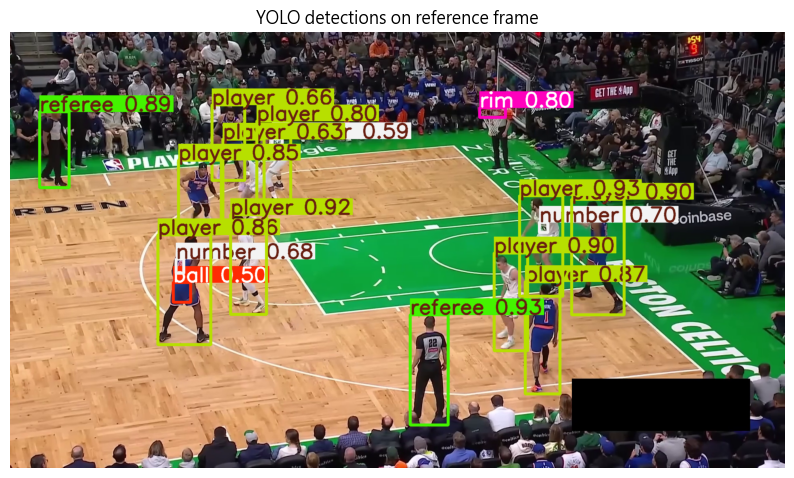

video: H:\Repos\basketball-hackathon-course\assets\raw\reference_videos\boston-celtics-new-york-knicks-game-1-q1-01.54-01.48.mp4
detections: 17
saved: H:\Repos\basketball-hackathon-course\assets\results\d1_03_yolo_detections.png


,frame_index,class_id,class_name,confidence,bbox_xyxy,track_id
0,15,3,player,0.934670,"[1262.3958740234375, 405.5896301269531, 1369.7...",None
1,15,8,referee,0.928363,"[991.0435791015625, 700.4292602539062, 1085.68...",None
2,15,3,player,0.923186,"[546.9348754882812, 452.7174072265625, 635.581...",None
3,15,3,player,0.904059,"[1199.249267578125, 547.012939453125, 1282.009...",None
4,15,3,player,0.898677,"[1391.560546875, 414.48876953125, 1521.7178955...",None


In [4]:
# 這一格要做什麼：Roboflow YOLO Detection Export 格式
# 建議先執行原始設定；確認輸出後，再一次只改一個參數觀察差異。
import cv2
import pandas as pd
from ultralytics import YOLO

from src.cv_utils import save_image_rgb, save_json, show_image
from src.yolo_utils import detections_from_result

video_candidates = sorted((COURSE_ROOT / "assets" / "raw" / "reference_videos").glob("*.mp4"))
if not video_candidates:
    raise FileNotFoundError("找不到參考影片。請確認 assets/raw/reference_videos/ 內至少有一支 mp4。")

video_path = video_candidates[0]
cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise FileNotFoundError(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 15)
ok, frame_bgr = cap.read()
cap.release()
if not ok:
    raise RuntimeError(f"無法讀取 frame 15: {video_path}")
frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

model = YOLO(str(DETECTOR_MODEL_PATH))
result = model.predict(frame, conf=0.25, imgsz=960, verbose=False)[0]
detections = detections_from_result(result, frame_index=15)
vis = result.plot().copy()
show_image(vis, "YOLO detections on reference frame")

out_image = COURSE_ROOT / "assets" / "results" / "d1_03_yolo_detections.png"
out_json = COURSE_ROOT / "assets" / "results" / "d1_03_yolo_detections.json"
save_image_rgb(out_image, vis)
save_json([record.__dict__ for record in detections], out_json)

print("video:", video_path)
print("detections:", len(detections))
print("saved:", out_image)
pd.DataFrame([record.__dict__ for record in detections]).head()


## 本單元產出檔案

- `assets/datasets/roboflow_bbox_yolo/data.yaml` 與對應 images / labels：Roboflow detection export。
- `assets/results/d1_03_yolo_detections.png`：單張 frame 的 YOLO detection 預覽圖。
- `assets/results/d1_03_yolo_detections.json`：單張 frame 的 detection 結果。
- 若 `RUN_TRAINING=True`，另外會產生 Ultralytics 訓練輸出目錄。
